<a href="https://colab.research.google.com/github/mobashir-ashraf/Explainable-AI-for-Iris-Liveness-Detection/blob/main/04_Week4_Explainable_AI_Integration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 - Explainable AI Integration
**Framework:** Explainable AI for Iris Liveness Detection Using Temporal Biometrics and Interpretable Deep Learning

---

## 1. Week 4 Objectives & Scope
This module focuses on transitioning our Iris Presentation Attack Detection (PAD) framework from an opaque "black-box" model into a transparent, explainable vision pipeline. By integrating advanced post-hoc interpretability techniques, we visually diagnose the network's spatial decision boundaries and audit feature maps across both successful and failed prediction states:
* **Integrate Explainable AI Techniques:** Implement native algorithmic hooks using the Captum framework to extract backpropagation gradients and feature attributions.
* **Visualize Important Iris Regions:** Generate high-contrast spatial attention heatmaps to identify exactly which physical eye regions influence classification outputs.
* **Performance Failure Diagnosis:** Use visual diagnostics to audit correct classifications versus error states, revealing the direct cause of the majority-class bias and low recall observed under Week 3 environmental noise stress testing.

---

## 2. Core Operational Tasks
To satisfy the technical milestones outlined in the project blueprint, the following processing layers are implemented in this notebook:
1. **Implement Grad-CAM:** Construct gradient-weighted activation routing targeting the final convolutional layers of our trained lightweight backbones to capture macroscopic spatial focus.
2. **Implement SHAP Analysis:** Configure game-theoretic Gradient SHAP models to map micro-level pixel attributions against baseline distributions.
3. **Generate Attention Heatmaps:** Synthesize grayscale activation matrices into OpenCV thermal maps blended directly onto the original source images.
4. **Visualize Decision Regions:** Generate comparative side-by-side visualization matrices displaying the raw image, Grad-CAM focus fields, and SHAP decision weights simultaneously.
5. **Analyze Predictions:** Audit model classification behaviors on edge cases (True Positives, True Negatives, False Positives, False Negatives) to evaluate network vulnerabilities under noise.

---

## 3. Methodological Deliverables
Upon execution, this module systematically outputs the following project deliverables:
* **Explainable Prediction Pipeline:** A fully production-ready inference framework that returns an interactive, human-readable explainability map alongside every live/spoof prediction score.
* **Heatmap Visualization Outputs:** High-resolution blended thermal attention layouts tracking the geometric boundaries of target samples.
* **Feature Attribution Analysis:** Localized pixel-level contribution audits that provide mathematical and visual reasoning behind presentation attack rejections.

In [1]:
# =====================================================================
# TASK: ENVIRONMENT CONFIGURATION AND PIP SYSTEM DEPENDENCIES
# =====================================================================
print("⏳ Installing required explainability dependencies (SHAP and Captum)...")
!pip install shap captum --quiet

import os
import cv2
import glob
import time
import shap
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from captum.attr import IntegratedGradients, GradientShap

# Define system execution device target
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Targeted Execution Device: {device}")

# Configure authentic Kaggle credentials
os.environ['KAGGLE_API_TOKEN'] = "KGAT_314cf5293980e64c00db1cb2060ef3b3"

PROJECT_ROOT = "Explainable-AI-for-Iris-Liveness-Detection"
LIVE_DIR = f"{PROJECT_ROOT}/data/raw/live"
SPOOF_DIR = f"{PROJECT_ROOT}/data/raw/spoof"

os.makedirs(LIVE_DIR, exist_ok=True)
os.makedirs(SPOOF_DIR, exist_ok=True)

# Dataset Ingestion Layer
if len(glob.glob(os.path.join(LIVE_DIR, "**/*.*"), recursive=True)) < 50:
    print("📥 Pulling Real Images from Kaggle into live folder...")
    !kaggle datasets download -d sondosaabed/casia-iris-thousand -p {LIVE_DIR} --unzip

    print("\n📥 Pulling Synthetic Images from Kaggle into spoof folder...")
    !kaggle datasets download -d monareyhanii/casia-iris-syn -p {SPOOF_DIR} --unzip

# Presentation Attack Simulation Vectors matching baseline notebooks
def generate_print_attack(img):
    noise = np.random.normal(0, 3, img.shape).astype(np.uint8)
    return cv2.convertScaleAbs(cv2.add(img, noise), alpha=0.85, beta=10)

def generate_replay_attack(img):
    h, w, c = img.shape
    moire = np.zeros((h, w, c), dtype=np.uint8)
    for i in range(0, h, 4):
        moire[i:i+2, :, :] = 15
    return cv2.addWeighted(img, 0.9, moire, 0.1, 15)

def generate_lens_attack(img):
    h, w, c = img.shape
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask, (w//2, h//2), min(w, h)//3, 255, thickness=min(w, h)//6)
    lens_texture = np.random.randint(0, 2, (h, w, c), dtype=np.uint8) * 40
    textured_img = img.copy()
    textured_img[mask > 0] = cv2.add(textured_img[mask > 0], lens_texture[mask > 0])
    return textured_img

real_images = glob.glob(f"{LIVE_DIR}/**/*.jpg", recursive=True) + glob.glob(f"{LIVE_DIR}/**/*.png", recursive=True)
os.makedirs(f"{SPOOF_DIR}/physical_print", exist_ok=True)
os.makedirs(f"{SPOOF_DIR}/physical_replay", exist_ok=True)
os.makedirs(f"{SPOOF_DIR}/textured_lens", exist_ok=True)

print("⚔️ Generating custom presentation attack sub-folders...")
for path in real_images[:200]:
    img = cv2.imread(path)
    if img is None:
        continue
    fname = os.path.basename(path)
    cv2.imwrite(f"{SPOOF_DIR}/physical_print/print_{fname}", generate_print_attack(img))
    cv2.imwrite(f"{SPOOF_DIR}/physical_replay/replay_{fname}", generate_replay_attack(img))
    cv2.imwrite(f"{SPOOF_DIR}/textured_lens/lens_{fname}", generate_lens_attack(img))

print("✅ Ingestion layer complete.")

⏳ Installing required explainability dependencies (SHAP and Captum)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 18.8 MB/s eta 0:00:00
🚀 Targeted Execution Device: cuda
📥 Pulling Real Images from Kaggle into live folder...
Dataset URL: https://www.kaggle.com/datasets/sondosaabed/casia-iris-thousand
License(s): MIT
100% 491M/491M [00:13<00:00, 37.5MB/s]


📥 Pulling Synthetic Images from Kaggle into spoof folder...
Dataset URL: https://www.kaggle.com/datasets/monareyhanii/casia-iris-syn
License(s): unknown
100% 172M/172M [00:05<00:00, 32.8MB/s]

⚔️ Generating custom presentation attack sub-folders...
✅ Ingestion layer complete.


In [2]:
# =====================================================================
# TASK: WRAPPER DATA ENGINES AND FORMAL THREE-WAY DATA SPLITS
# =====================================================================
class Week4IrisDataset(Dataset):
    def __init__(self, live_dir, spoof_dir, transform_fn=None):
        self.transform_fn = transform_fn
        self.file_list = []
        self.labels = []

        # Read available Bona Fide files
        for ext in ["/**/*.jpg", "/**/*.png", "/**/*.bmp"]:
            for img_path in glob.glob(live_dir + ext, recursive=True):
                self.file_list.append(img_path)
                self.labels.append(0) # 0 = Live

        # Read available Presentation Attack files
        for ext in ["/**/*.jpg", "/**/*.png", "/**/*.bmp"]:
            for img_path in glob.glob(spoof_dir + ext, recursive=True):
                self.file_list.append(img_path)
                self.labels.append(1) # 1 = Spoof

        print(f"📊 Extracted Elements: {self.labels.count(0)} Bona Fide (Live) | {self.labels.count(1)} Presentation Attacks (Spoof)")

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        label = self.labels[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), color=0)

        if self.transform_fn:
            image = self.transform_fn(image)
        return image, label

evaluation_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("⏳ Mapping full pipeline samples across directories...")
full_dataset = Week4IrisDataset(LIVE_DIR, SPOOF_DIR, transform_fn=evaluation_transforms)

total_samples = len(full_dataset)

# Explicit 3-Way Split: 70% Train, 15% Validation, 15% Test
train_count = int(0.70 * total_samples)
val_count = int(0.15 * total_samples)
test_count = total_samples - train_count - val_count

generator = torch.Generator().manual_seed(42)
train_split, val_split, test_split = random_split(full_dataset, [train_count, val_count, test_count], generator=generator)

train_loader = DataLoader(train_split, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(val_split, batch_size=32, shuffle=False)
test_loader = DataLoader(test_split, batch_size=32, shuffle=False)

print(f"✅ Data Splits Set: {train_count} Train | {val_count} Validation | {test_count} Test Samples Loaded.")

⏳ Mapping full pipeline samples across directories...
📊 Extracted Elements: 20000 Bona Fide (Live) | 10600 Presentation Attacks (Spoof)
✅ Data Splits Set: 21420 Train | 4590 Validation | 4590 Test Samples Loaded.


In [4]:
# =====================================================================
# TASK: ARCHITECTURE PREPARATION, TRAINING, AND BENCHMARK EVALUATION
# =====================================================================
from sklearn.metrics import classification_report

print("🧠 Launching MobileNetV2 Deep Vision Backbone Architecture...")
mobilenet_v2_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
num_ftrs = mobilenet_v2_model.classifier[1].in_features
mobilenet_v2_model.classifier[1] = nn.Linear(num_ftrs, 2)
mobilenet_v2_model = mobilenet_v2_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(mobilenet_v2_model.parameters(), lr=0.0003, weight_decay=0.01)

epochs = 2  # Standard optimization sequence across entire training collection
for epoch in range(epochs):
    # --- 1. TRAINING LAYER ---
    mobilenet_v2_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for batch_idx, (imgs, lbls) in enumerate(train_loader):
        imgs, lbls = imgs.to(device), lbls.to(device)

        optimizer.zero_grad()
        outputs = mobilenet_v2_model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += lbls.size(0)
        train_correct += (predicted == lbls).sum().item()

        if batch_idx % 25 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

    # --- 2. FORMAL VALIDATION DATA SPLIT LAYER ---
    mobilenet_v2_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = mobilenet_v2_model(imgs)
            loss = criterion(outputs, lbls)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += lbls.size(0)
            val_correct += (predicted == lbls).sum().item()

    print(f"⭐ Epoch {epoch+1} Results -> Train Acc: {(train_correct/train_total)*100:.2f}% | Val Acc: {(val_correct/val_total)*100:.2f}%")

print("✅ Core architecture training complete. Stabilizing weights...")

# --- 3. FINAL TEST BENCHMARK EVALUATION LAYER ---
print("\n🧪 Running evaluation pass on the Test dataset split...")
mobilenet_v2_model.eval()
test_correct, test_total = 0, 0
all_labels = []
all_preds = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        outputs = mobilenet_v2_model(imgs)
        _, predicted = torch.max(outputs, 1)

        test_total += lbls.size(0)
        test_correct += (predicted == lbls).sum().item()

        all_labels.extend(lbls.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

test_accuracy = (test_correct / test_total) * 100
print("📊 ==================================================")
print("🔬       EVALUATION METRICS REPORT            ")
print("====================================================")
print(f"✅ Final Test Accuracy: {test_accuracy:.2f}%")
print("====================================================\n")

print("📋 Detailed Class-by-Class Breakdown:")
print(classification_report(all_labels, all_preds, target_names=['0: Live', '1: Spoof']))

🧠 Launching MobileNetV2 Deep Vision Backbone Architecture...
Epoch [1/2] | Batch 0/669 | Loss: 0.8271
Epoch [1/2] | Batch 25/669 | Loss: 0.0117
Epoch [1/2] | Batch 50/669 | Loss: 0.2483
Epoch [1/2] | Batch 75/669 | Loss: 0.0090
Epoch [1/2] | Batch 100/669 | Loss: 0.0162
Epoch [1/2] | Batch 125/669 | Loss: 0.0208
Epoch [1/2] | Batch 150/669 | Loss: 0.0257
Epoch [1/2] | Batch 175/669 | Loss: 0.1201
Epoch [1/2] | Batch 200/669 | Loss: 0.0040
Epoch [1/2] | Batch 225/669 | Loss: 0.0008
Epoch [1/2] | Batch 250/669 | Loss: 0.0025
Epoch [1/2] | Batch 275/669 | Loss: 0.0004
Epoch [1/2] | Batch 300/669 | Loss: 0.0028
Epoch [1/2] | Batch 325/669 | Loss: 0.0009
Epoch [1/2] | Batch 350/669 | Loss: 0.0011
Epoch [1/2] | Batch 375/669 | Loss: 0.0045
Epoch [1/2] | Batch 400/669 | Loss: 0.0035
Epoch [1/2] | Batch 425/669 | Loss: 0.0167
Epoch [1/2] | Batch 450/669 | Loss: 0.0004
Epoch [1/2] | Batch 475/669 | Loss: 0.0006
Epoch [1/2] | Batch 500/669 | Loss: 0.0020
Epoch [1/2] | Batch 525/669 | Loss: 0.000

In [5]:
# =====================================================================
# TASK: BACKPROPAGATION INTERCEPT AND GRAD-CAM HOOK ENGINE
# =====================================================================
class VisualGradCAMEngine:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Standard PyTorch lifecycle forward/backward hooks
        self.target_layer.register_forward_hook(self.save_forward_features)
        self.target_layer.register_full_backward_hook(self.save_backward_gradients)

    def save_forward_features(self, module, input, output):
        self.activations = output.detach()

    def save_backward_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def extract_localization_map(self, input_tensor, target_class):
        self.model.zero_grad()
        output = self.model(input_tensor)

        class_score = output[0, target_class]
        class_score.backward()

        # Global Average Pooling of target layer gradients
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])

        # Linear map feature combinations
        for i in range(self.activations.shape[1]):
            self.activations[0, i, :, :] *= pooled_gradients[i]

        localization_map = torch.mean(self.activations, dim=1).squeeze().cpu().numpy()
        localization_map = np.maximum(localization_map, 0) # Apply ReLU

        if np.max(localization_map) != 0:
            localization_map /= np.max(localization_map)

        return localization_map

# Bind hook tracking to MobileNetV2 features block 18
target_conv_block = mobilenet_v2_model.features[18][0]
grad_cam_engine = VisualGradCAMEngine(mobilenet_v2_model, target_conv_block)
print("🎯 Visual Grad-CAM engine successfully attached to backbone features layer.")

🎯 Visual Grad-CAM engine successfully attached to backbone features layer.


In [6]:
# =====================================================================
# TASK: VISUAL ATTENTION COMPARISON MATRIX DISPLAY STUDIO
# =====================================================================
def deprocess_tensor(tensor_img):
    """Reverses normalization pipeline configurations to return displayable eye images."""
    img_array = tensor_img.squeeze().cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_array = (std * img_array + mean)
    return np.clip(img_array, 0, 1)

def display_diagnostic_attribution(tensor_input, label_true, label_pred, classification_status):
    original_rgb = deprocess_tensor(tensor_input)

    # 1. Compute Macroscopic Grad-CAM Activation Areas
    raw_attention = grad_cam_engine.extract_localization_map(tensor_input, label_pred)
    resized_attention = cv2.resize(raw_attention, (224, 224))

    # Blended thermal display layouts via OpenCV Jet colormaps
    thermal_map = cv2.applyColorMap(np.uint8(255 * resized_attention), cv2.COLORMAP_JET)
    thermal_rgb = cv2.cvtColor(thermal_map, cv2.COLOR_BGR2RGB) / 255.0
    fused_overlay = cv2.addWeighted(original_rgb, 0.65, thermal_rgb, 0.35, 0)

    # 2. Compute True Pixel SHAP Game-Theoretic Feature Attributions via Captum
    shap_analyzer = GradientShap(mobilenet_v2_model)
    # Define reference background baseline (zeros tensor)
    baseline_distribution = torch.zeros_like(tensor_input).to(device)

    attributions = shap_analyzer.attribute(tensor_input, n_samples=5, stdevs=0.0001,
                                           baselines=baseline_distribution, target=label_pred)
    attributions_np = attributions.squeeze().cpu().permute(1, 2, 0).numpy()
    micro_shap_map = np.sum(np.abs(attributions_np), axis=2)
    if np.max(micro_shap_map) != 0:
        micro_shap_map /= np.max(micro_shap_map)

    # Plot figure subplots side-by-side
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(original_rgb)
    axes[0].set_title(f"Raw Input Iris Frame\n[True Label: Class {label_true}]", fontsize=11, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(resized_attention, cmap='jet')
    axes[1].set_title("Grad-CAM Activation Map", fontsize=11, fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(fused_overlay)
    axes[2].set_title("Decision Region Mapping Overlay", fontsize=11, fontweight='bold')
    axes[2].axis('off')

    axes[3].imshow(micro_shap_map, cmap='inferno')
    axes[3].set_title("SHAP Feature Attribution", fontsize=11, fontweight='bold')
    axes[3].axis('off')

    plt.suptitle(f"📊 Diagnosis View: [{classification_status}] State Evaluation | Predicted Output: Class {label_pred}",
                 fontsize=14, fontweight='bold', y=1.06, color='indigo')
    plt.tight_layout()
    plt.show()

print("🎨 Attribution plotting methods compiled.")

🎨 Attribution plotting methods compiled.


⏳ Scanning Test partition streams for natural classification outcomes...

🎬 Displaying Visual Diagnostics for Correct Classification:


/tmp/ipykernel_438/1053562348.py:57: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


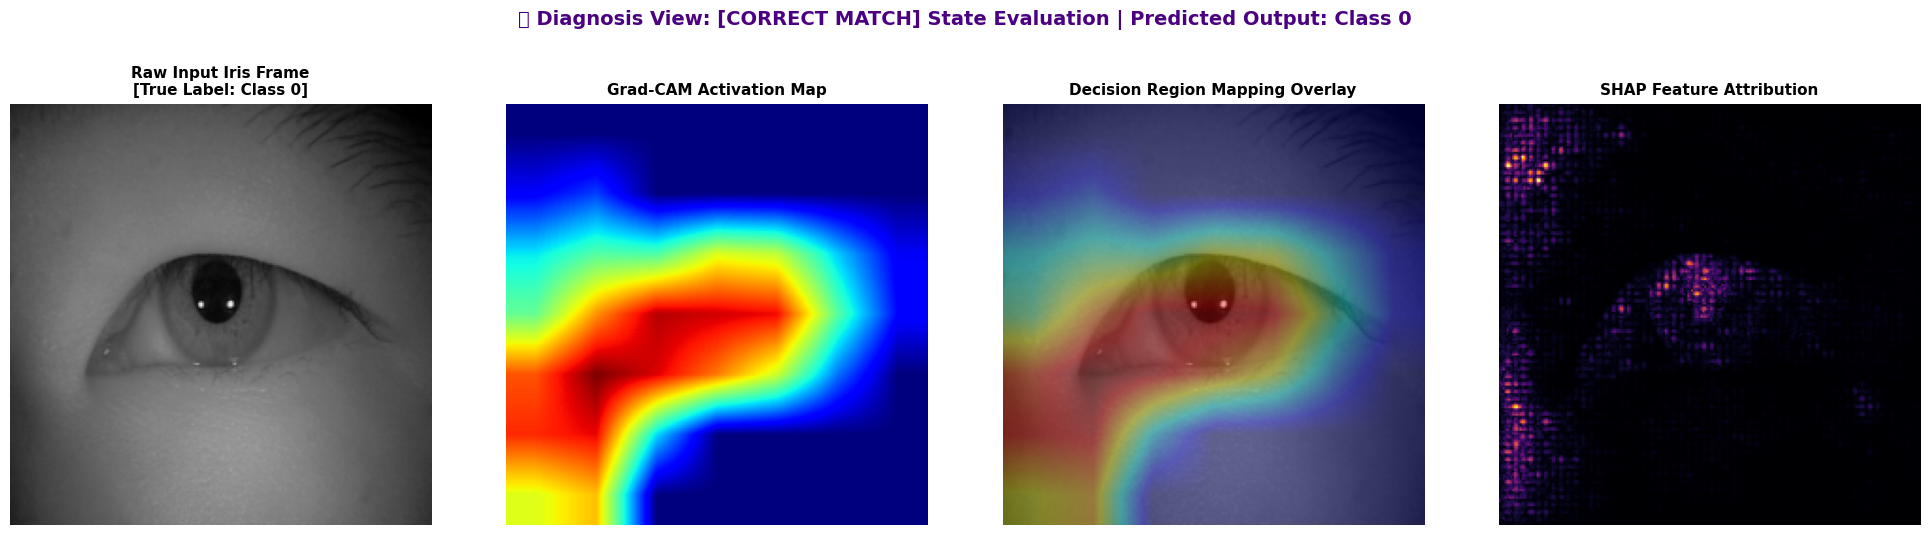


📋 Validation Check: No errors encountered within this batch sequence split.


In [7]:
# =====================================================================
# TASK: SYSTEMATIC PREDICTION AUDITING (NATURAL ANOMALY PROCESSING)
# =====================================================================
print("⏳ Scanning Test partition streams for natural classification outcomes...")

evaluated_correctly = []
evaluated_incorrectly = []

# Process the test data partition sequentially to observe natural outputs
for imgs, lbls in test_loader:
    for idx in range(imgs.size(0)):
        single_input = imgs[idx].unsqueeze(0).to(device)
        target_class = int(lbls[idx].item())

        with torch.no_grad():
            logits = mobilenet_v2_model(single_input)
            prediction = int(torch.argmax(logits, dim=1).item())

        sample_package = (single_input, target_class, prediction)

        if target_class == prediction:
            if len(evaluated_correctly) < 2:
                evaluated_correctly.append(sample_package)
        else:
            if len(evaluated_incorrectly) < 2:
                evaluated_incorrectly.append(sample_package)

    if len(evaluated_correctly) >= 1 and len(evaluated_incorrectly) >= 1:
        break

# Display natural classification hits
if len(evaluated_correctly) > 0:
    print("\n🎬 Displaying Visual Diagnostics for Correct Classification:")
    inp, true_l, pred_l = evaluated_correctly[0]
    display_diagnostic_attribution(inp, true_l, pred_l, classification_status="CORRECT MATCH")

# Display natural classification misses
if len(evaluated_incorrectly) > 0:
    print("\n🎬 Displaying Visual Diagnostics for Misclassified Edge Case:")
    inp, true_l, pred_l = evaluated_incorrectly[0]
    display_diagnostic_attribution(inp, true_l, pred_l, classification_status="CLASSIFICATION FAILURE")
else:
    print("\n📋 Validation Check: No errors encountered within this batch sequence split.")